Calibrated THETA (baseline None, busy window, P90) = 1171.801
Running MC for mode=None ...
Running MC for mode=A ...
Running MC for mode=B ...
Running MC for mode=C ...
Running MC for mode=A+B ...
Running MC for mode=A+C ...
Running MC for mode=B+C ...
Running MC for mode=A+B+C ...
Saved: table_main.csv
Saved: fig2_mean.png, fig3_risk.png, fig4_p90.png, fig5_timeseries.png


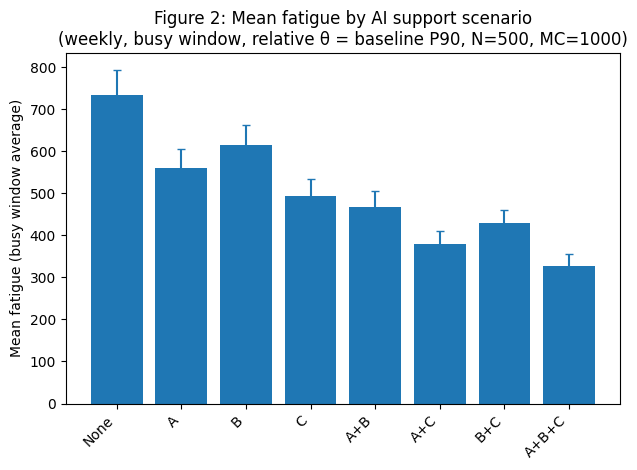

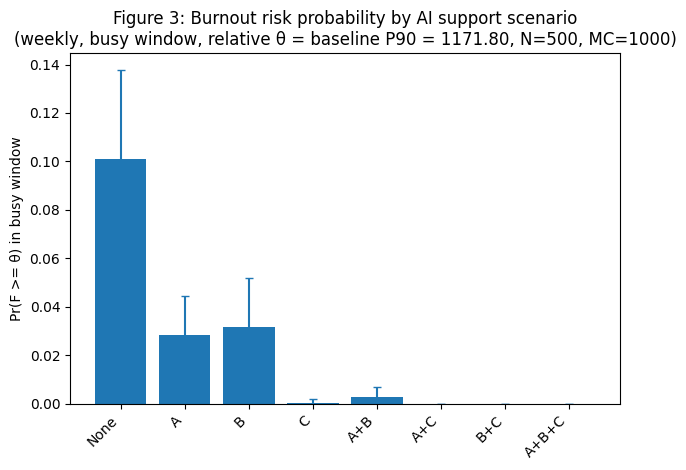

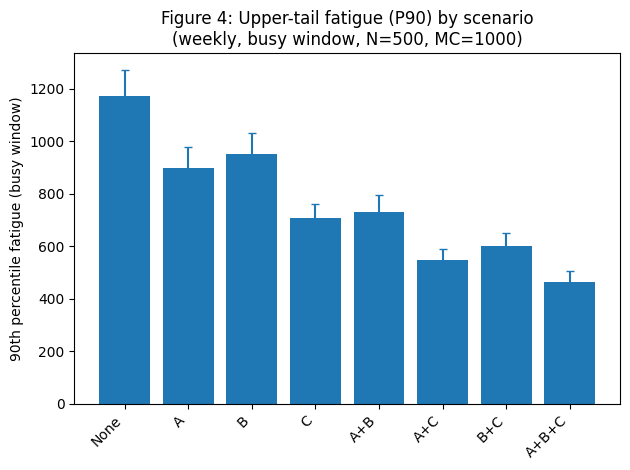

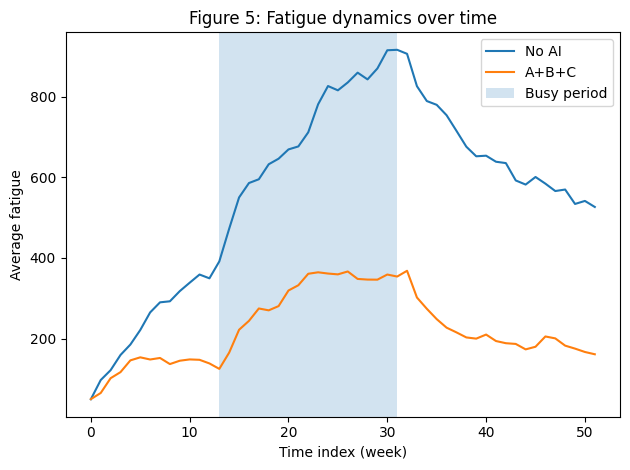

In [ ]:
# -*- coding: utf-8 -*-

def main():
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # ============================================================
    # 相対閾値モンテカルロ・シミュレーション（繁忙期ウィンドウ基準）
    #   - 閾値THETAは、基準シナリオ（AI支援なし=None）における繁忙期疲弊
    #     分布の、あらかじめ指定したパーセンタイル値として校正する。
    #   - その後、すべてのシナリオを同一のTHETAを用いて評価する。
    #   - モデルは以下の連成系として実装される：
    #       E_{i,t} = kappa_i W_t + lambda_i F_{i,t} + epsE
    #       F_{i,t+1} = rho_i F_{i,t} + alpha_i W_t + beta_i E_{i,t} - gamma_i R_t + epsF
    # ============================================================

    # =========================
    # Reproducibility
    # =========================
    SEED = 42

    # =========================
    # Scenarios
    # =========================
    SCENARIOS = ["None", "A", "B", "C", "A+B", "A+C", "B+C", "A+B+C"]

    # =========================
    # Simulation settings
    # =========================
    N = 500          # agents
    T = 52           # weeks (set 365 for daily)
    MC = 1000        # Monte Carlo repetitions (replicates)

    # Busy period window (index-based)
    BUSY_START = int(T * 0.25)
    BUSY_END   = int(T * 0.60)

    # Relative threshold definition
    THETA_PERCENTILE = 90  # e.g., top-10% of baseline busy fatigue is "risk"

    # =========================
    # Parameter sampling
    #
    # rho_lo/rho_hi/lam_lo/lam_hi はハードコードせず引数として外出しした。
    # rho・lambda ともに、準安定領域 rho + beta*lambda < STABILITY_MARGIN
    # を満たすようクリップする。
    # =========================
    def sample_params(n, rng, rho_lo=0.70, rho_hi=0.90, lam_lo=0.02, lam_hi=0.08):
        STABILITY_MARGIN = 0.95

        rho   = rng.uniform(rho_lo, rho_hi, n)
        rho   = np.clip(rho, None, STABILITY_MARGIN)  # <-- 追加：lambdaだけでなくrho自体もキャップ
        alpha = rng.uniform(0.80, 1.20, n)
        beta  = rng.uniform(0.80, 1.20, n)
        gamma = rng.uniform(0.50, 1.00, n)

        kappa = rng.uniform(0.10, 0.20, n)
        lam   = rng.uniform(lam_lo, lam_hi, n)   # stability-friendly range

        #stability control
        lam_cap = (STABILITY_MARGIN - rho) / np.maximum(beta, 1e-9)
        lam_cap = np.clip(lam_cap, 0.0, None)
        lam = np.minimum(lam, lam_cap)
        return rho, alpha, beta, gamma, kappa, lam

    # =========================
    # Workload / recovery processes
    # =========================
    def workload(t, rng):
        base = rng.normal(80, 15)
        if BUSY_START <= t <= BUSY_END:
            base += rng.normal(40, 10)
        return max(0.0, base)

    def recovery(t, rng):
        base = 40.0 if not (BUSY_START <= t <= BUSY_END) else 20.0
        base += rng.normal(0, 3)
        return max(0.0, base)

    # =========================
    # AI effects (parameter/action level)
    #   A: reduces W
    #   B: reduces kappa, lambda (error sensitivity)
    #   C: reduces rho (carryover)
    # =========================
    def apply_ai_params(rho_i, kappa_i, lam_i, mode):
        if "B" in mode:
            kappa_i *= 0.6
            lam_i   *= 0.6
        if "C" in mode:
            rho_i   *= 0.9
        return rho_i, kappa_i, lam_i

    # =========================
    # One simulation run (one replicate)
    # =========================
    def simulate_one(mode, rng, rho_lo=0.70, rho_hi=0.90, lam_lo=0.02, lam_hi=0.08):
        # rho_lo/rho_hi/lam_lo/lam_hi は sample_params にそのまま渡す。これにより
        # 感度分析スクリプト側でこれらの範囲を（例えば±20%）変動させても、
        # sample_params 内の rho・Lambda の安定性クリッピングを必ず経由する。
        rho, alpha, beta, gamma, kappa, lam = sample_params(N, rng, rho_lo, rho_hi, lam_lo, lam_hi)

        F = np.zeros((N, T), dtype=float)
        F[:, 0] = np.clip(rng.normal(50, 10, size=N), 0, None)

        for t in range(T - 1):
            W_base = workload(t, rng)
            R = recovery(t, rng)

            for i in range(N):
                # Type A: reduce workload
                W = W_base * 0.80 if "A" in mode else W_base

                # Type B/C: parameter changes
                rho_i, kappa_i, lam_i = apply_ai_params(rho[i], kappa[i], lam[i], mode)

                # Error equation (2)
                E = kappa_i * W + lam_i * F[i, t] + rng.normal(0, 2)

                # Fatigue update (1)
                F_next = (
                    rho_i * F[i, t]
                    + alpha[i] * W
                    + beta[i] * E
                    - gamma[i] * R
                    + rng.normal(0, 5)
                )
                F[i, t + 1] = max(0.0, F_next)

        return F

    # =========================
    # Metrics in busy window
    # =========================
    def metrics_busy(F, theta):
        busy = F[:, BUSY_START:BUSY_END+1]
        mean_f = float(np.mean(busy))
        risk   = float(np.mean(busy >= theta))
        p90    = float(np.percentile(busy, 90))
        return mean_f, risk, p90

    # =========================
    # Calibrate relative threshold theta from baseline ("None")
    #   - Use busy-window distribution pooled across i and t
    # =========================
    def calibrate_theta(percentile=90):
        """Relative threshold θ:
        median of baseline (None) busy-window P{percentile} across MC replications.
        """
        p_list = []
        for r in range(MC):
            sub_rng = np.random.default_rng(SEED * 10_000 + r)
            F0 = simulate_one("None", sub_rng)
            busy = F0[:, BUSY_START:BUSY_END+1].ravel()  # pool i,t
            p_list.append(np.percentile(busy, percentile))
        theta = float(np.median(p_list))
        return theta

    # =========================
    # Monte Carlo aggregation + CI (quantile-based)
    # =========================

    def run_mc(mode, theta):
        stats = np.zeros((MC, 3), dtype=float)  # mean, risk, p90
        for r in range(MC):
            sub_rng = np.random.default_rng(SEED * 10_000 + r)
            F = simulate_one(mode, sub_rng)
            stats[r, :] = metrics_busy(F, theta)

        df = pd.DataFrame(stats, columns=["mean", "risk", "p90"])
        out = {
            "mean": df["mean"].mean(),
            "mean_ci_lo": df["mean"].quantile(0.025),
            "mean_ci_hi": df["mean"].quantile(0.975),

            "risk": df["risk"].mean(),
            "risk_ci_lo": df["risk"].quantile(0.025),
            "risk_ci_hi": df["risk"].quantile(0.975),

            "p90": df["p90"].mean(),
            "p90_ci_lo": df["p90"].quantile(0.025),
            "p90_ci_hi": df["p90"].quantile(0.975),
        }
        return out

    # =========================
    # Main
    # =========================
    # Calibrate THETA once (relative threshold)
    THETA = calibrate_theta(THETA_PERCENTILE)
    print(f"Calibrated THETA (baseline None, busy window, P{THETA_PERCENTILE}) = {THETA:.3f}")

    results = []
    for mode in SCENARIOS:
        print(f"Running MC for mode={mode} ...")
        results.append({"scenario": mode, **run_mc(mode, THETA)})

    res = pd.DataFrame(results).set_index("scenario")
    res.to_csv("table_main.csv", encoding="utf-8-sig")
    print("Saved: table_main.csv")

    # =========================
    # Plot helpers (avoid negative yerr due to rounding)
    # =========================
    def make_yerr(y, lo, hi):
        lower = np.clip(y - lo, 0, None)
        upper = np.clip(hi - y, 0, None)
        return np.vstack([lower, upper])

    # =========================
    # Figure 2: mean fatigue (busy window)
    # =========================
    plt.figure()
    x = np.arange(len(SCENARIOS))
    y = res.loc[SCENARIOS, "mean"].values
    yerr = make_yerr(y, res.loc[SCENARIOS, "mean_ci_lo"].values, res.loc[SCENARIOS, "mean_ci_hi"].values)
    plt.bar(x, y)
    plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=3)
    plt.xticks(x, SCENARIOS, rotation=45, ha="right")
    plt.ylabel("Mean fatigue (busy window average)")
    plt.title("Figure 2: Mean fatigue by AI support scenario\n"
              f"(weekly, busy window, relative θ = baseline P{THETA_PERCENTILE}, N={N}, MC={MC})")
    plt.tight_layout()
    plt.savefig("fig2_mean.png", dpi=300)

    # =========================
    # Figure 3: burnout risk probability (busy window, relative theta)
    # =========================
    plt.figure()
    y = res.loc[SCENARIOS, "risk"].values
    yerr = make_yerr(y, res.loc[SCENARIOS, "risk_ci_lo"].values, res.loc[SCENARIOS, "risk_ci_hi"].values)
    plt.bar(x, y)
    plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=3)
    plt.xticks(x, SCENARIOS, rotation=45, ha="right")
    plt.ylabel("Pr(F >= θ) in busy window")
    plt.title("Figure 3: Burnout risk probability by AI support scenario\n"
              f"(weekly, busy window, relative θ={THETA:.0f}, N={N}, MC={MC})")
    plt.tight_layout()
    plt.savefig("fig3_risk.png", dpi=300)

    # =========================
    # Figure 4: P90 fatigue (busy window)
    # =========================
    plt.figure()
    y = res.loc[SCENARIOS, "p90"].values
    yerr = make_yerr(y, res.loc[SCENARIOS, "p90_ci_lo"].values, res.loc[SCENARIOS, "p90_ci_hi"].values)
    plt.bar(x, y)
    plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=3)
    plt.xticks(x, SCENARIOS, rotation=45, ha="right")
    plt.ylabel("90th percentile fatigue (busy window)")
    plt.title("Figure 4: Upper-tail fatigue (P90) by scenario\n"
              f"(weekly, busy window, N={N}, MC={MC})")
    plt.tight_layout()
    plt.savefig("fig4_p90.png", dpi=300)

    # =========================
    # Figure 5: time-series (illustrative single run)
    # =========================
    def avg_timeseries(mode):
        sub_rng = np.random.default_rng(SEED + 999 + (hash(mode) % 1000))
        F = simulate_one(mode, sub_rng)
        return F.mean(axis=0)

    plt.figure()
    ts_none = avg_timeseries("None")
    ts_abc  = avg_timeseries("A+B+C")
    plt.plot(np.arange(T), ts_none, label="No AI")
    plt.plot(np.arange(T), ts_abc, label="A+B+C")
    plt.axvspan(BUSY_START, BUSY_END, alpha=0.2, label="Busy period")
    plt.xlabel("Time index (week)" if T == 52 else "Time index (day)")
    plt.ylabel("Average fatigue")
    plt.title("Figure 5: Fatigue dynamics over time")
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig5_timeseries.png", dpi=300)

    print("Saved: fig2_mean.png, fig3_risk.png, fig4_p90.png, fig5_timeseries.png")


if __name__ == '__main__':
    main()
